# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The data tracks 17 core banking telemarketing campaigns conducted by a Portuguese retail bank between May 2008 and November 2010 (a period heavily impacted by the European financial crisis).

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [ ]:
import requests
import zipfile
import io
import pandas as pd

# URL for the dataset
url = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'

print(f"Downloading dataset from: {url}")

# Download the zip file
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors

# Get the dataset zip file
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Get all contents to the current directory
    z.extractall('.')
    print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [ ]:
import zipfile
import os
#The target dataset is located in file bank-additional.zip
zip_file_name = 'bank-additional.zip'

if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"'{zip_file_name}' unzipped successfully.")
else:
    print(f"Error: '{zip_file_name}' not found. Please ensure it was downloaded.")

'bank-additional.zip' unzipped successfully.


In [ ]:
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep = ';')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [ ]:
# Null values check - The dataset has no null values
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
#Check for duplicate rows
print(f'Duplicate rows : {df.duplicated().sum()}')

Duplicate rows : 12


In [ ]:
#Dropping the 12 duplicate rows
print(f"Shape before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Shape before dropping duplicates: (41188, 21)
Shape after dropping duplicates: (41176, 21)


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

In [ ]:
#Filter out all the categorical columns (Object)
object_columns = df.select_dtypes(include='object').columns
# Evaluate counts of the categorical datatypes
for col in object_columns:
  # Check if the column exists in the DataFrame before accessing it
  if col in df.columns:
    #print("\n")
    print(df[col].value_counts())
    print(f"Column: {col} and number of categories: {df[col].nunique()}")
    print("\n")
  else:
    print(f"Column '{col}' not found in the DataFrame.")

job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
Column: job and number of categories: 12


marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64
Column: marital and number of categories: 4


education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64
Column: education and number of categories: 8


default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64
Column: default and number of categories: 3


housing
yes        21571
no         18615
unknown   

In [ ]:
# Display descriptive statistics for numerical columns
print(df.describe())

               age      duration      campaign         pdays      previous  \
count  41176.00000  41176.000000  41176.000000  41176.000000  41176.000000   
mean      40.02380    258.315815      2.567879    962.464810      0.173013   
std       10.42068    259.305321      2.770318    186.937102      0.494964   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41176.000000    41176.000000   41176.000000  41176.000000  41176.000000  
mean       0.081922       93.575720     -40.502863      3.621293   5167.034870  
std        1.570883        0.578839       4.627860    

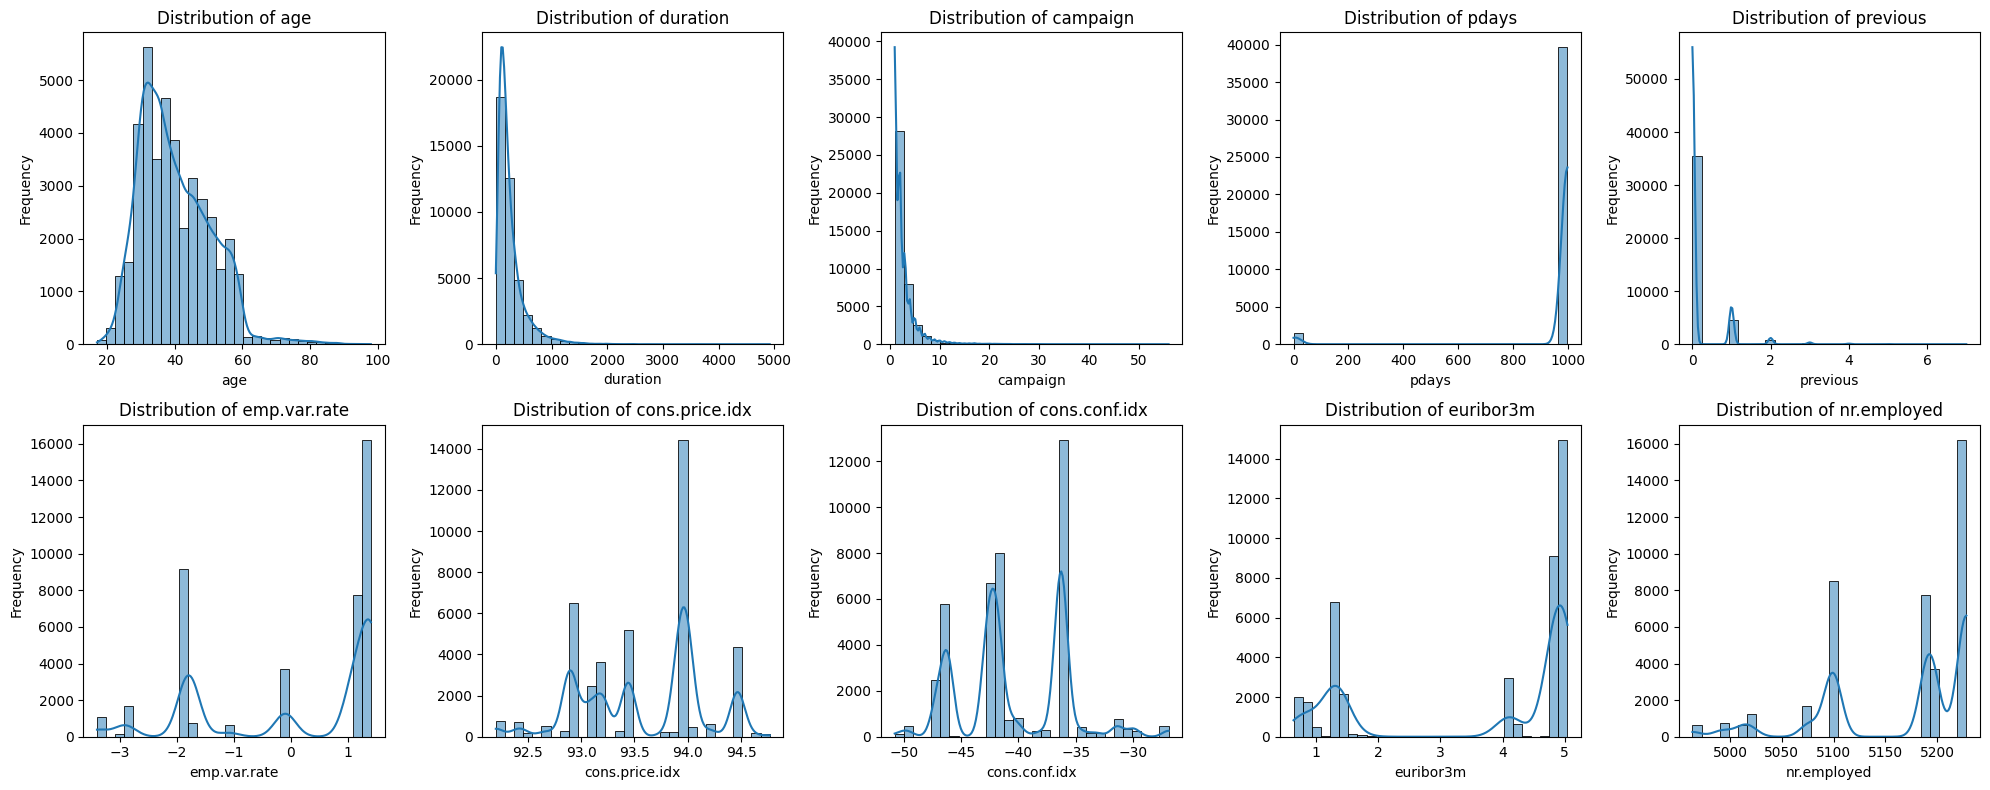

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all numerical columns for plotting
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

plt.figure(figsize=(20, 8)) # Adjusted figure size for a 2x5 grid
# Adjust subplot grid to 2x5 for the 10 numerical columns
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 5, i + 1) # Changed from 3x3 to 2x5 to accommodate 10 columns
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

-- --
#### Summary of Numerical Feature Analysis

Based on the descriptive statistics and distribution plots of the numerical features, the following observations can be made:

*   **Age:** The age distribution appears to be somewhat normally distributed, centered around 40, with a range from 17 to 98 years. There are no obvious outliers.
*   **Duration:** This feature is highly right-skewed, with most contact durations being short. As previously noted, the minimum duration of 0 seconds is particularly important due to its implications for data leakage.
*   **Campaign:** The number of contacts made during this campaign is also highly right-skewed, indicating that most clients were contacted only a few times. A small number of clients were contacted many times.
*   **Pdays:** This feature is heavily concentrated at 999, which signifies that the client was not previously contacted. This suggests that 'pdays' might be better represented as a categorical or binary feature (contacted previously vs. not contacted).
*   **Previous:** Similar to 'campaign', this feature is right-skewed, with most clients having had zero previous contacts before this campaign.
*   **Economic Indicators (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed):** These macroeconomic variables show varied distributions. Some might exhibit multiple modes, indicating different economic periods, while others might be more uniformly distributed across certain ranges. These features will be crucial for capturing external influences on term deposit subscriptions.

-- --
### Visualizing Key Variable Composition

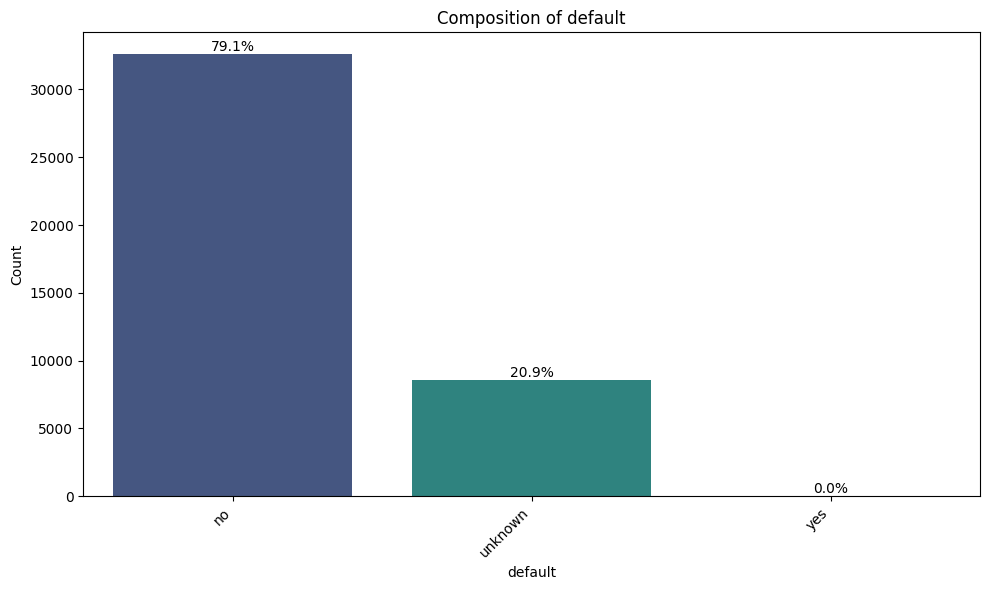

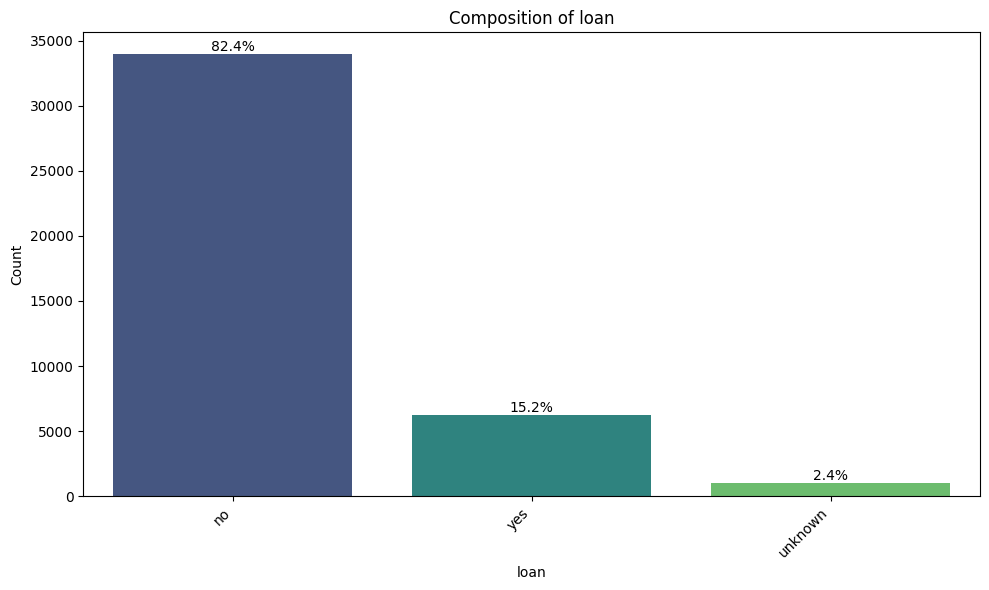

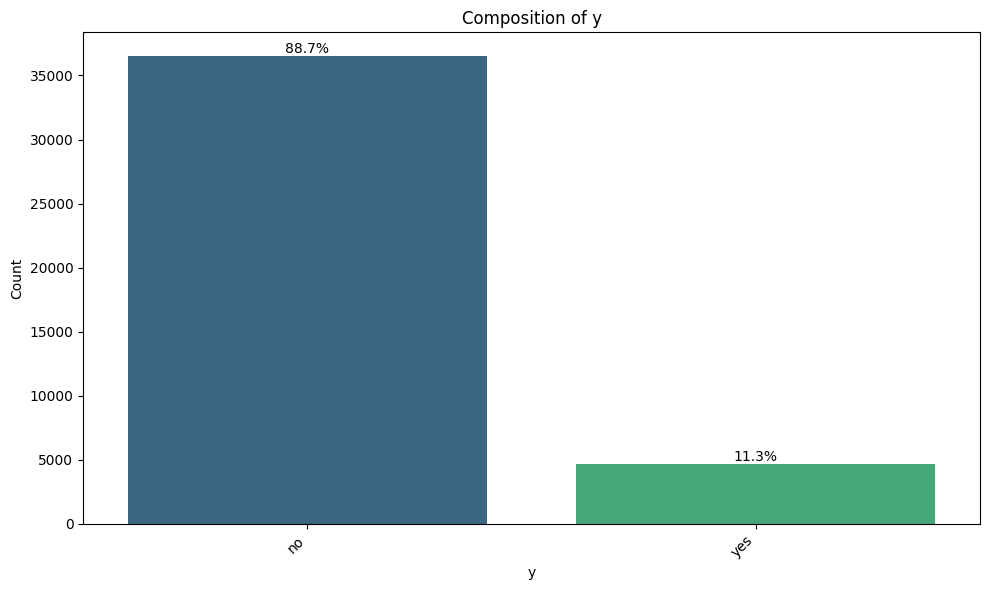

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot composition for some key columns
key_columns = ['default', 'loan', 'y']

for col in key_columns:
    plt.figure(figsize=(10, 6)) # Set a consistent figure size
    # Address FutureWarning by assigning x to hue and setting legend=False
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis', hue=col, legend=False)

    # Calculate percentages and add them to the bars
    total = len(df[col])
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom') # Annotate each bar

    plt.title(f'Composition of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

### Feature Engineering: Encoding and Transformation

To prepare the data for modeling, we need to handle categorical features by encoding them into a numerical format that machine learning algorithms can understand. We will use one-hot encoding for the categorical variables and convert the target variable `y` into a binary numerical representation (0 for 'no' and 1 for 'yes'). We will focus on the 'bank client data' features as requested.

### Dropping the 'duration' column

The 'duration' attribute should be discarded if the intention is to have a realistic predictive model, as its value is not known before a call is performed. Including it would lead to data leakage and an overly optimistic model performance. Therefore, we will drop this column.

In [ ]:
df.drop('duration', axis=1, inplace=True)
print("Dropped 'duration' column from the DataFrame.")
print(f"New shape of DataFrame: {df.shape}")
df.info()

Dropped 'duration' column from the DataFrame.
New shape of DataFrame: (41176, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  campaign        41176 non-null  int64  
 11  pdays           41176 non-null  int64  
 12  previous        41176 non-null  int64  
 13  poutcome        41176 non-null  object 
 14  emp.var.rate    41176 non-null  float64
 15  cons.price.idx  41176 non-null  float64
 16 

In [ ]:
# Define bank client data features based on the description
bank_client_features = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan'
]

# Separate features (X) and target (y)
X = df[bank_client_features]
y = df['y']

# Identify categorical columns within the selected features
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert the target variable 'y' to numerical (0 for 'no', 1 for 'yes')
y_encoded = y.map({'no': 0, 'yes': 1})

print("Shape of original features (bank client data):", X.shape)
print("Shape of encoded features (X_encoded):", X_encoded.shape)
print("First 5 rows of encoded features:")
display(X_encoded.head())
print("First 5 values of encoded target (y_encoded):")
display(y_encoded.head())

Shape of original features (bank client data): (41176, 7)
Shape of encoded features (X_encoded): (41176, 28)
First 5 rows of encoded features:


,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
0,56,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,57,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,37,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,40,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


First 5 values of encoded target (y_encoded):


,y
0,0
1,0
2,0
3,0
4,0


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (32940, 28)
Shape of X_test: (8236, 28)
Shape of y_train: (32940,)
Shape of y_test: (8236,)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [ ]:
# Calculate the baseline accuracy by predicting the majority class
majority_class = y_train.mode()[0]
baseline_accuracy = (y_train == majority_class).mean()

print(f"Majority class in y_train: {majority_class}")
print(f"Baseline accuracy (predicting majority class): {baseline_accuracy:.4f}")

Majority class in y_train: 0
Baseline accuracy (predicting majority class): 0.8873


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg = LogisticRegression(solver='liblinear', random_state=42)

# Fit the model to the training data
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Problem 9: Score the Model

What is the accuracy of your model?

In [ ]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

Logistic Regression Model Accuracy: 0.8873


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

### Problem 10: Model Comparisons

To compare the performance of different models, we will train K-Nearest Neighbors (KNN), Decision Trees, and Support Vector Machines (SVM) using default parameters. We will record their training time, training accuracy, and test accuracy. Finally, these results will be presented in a comparative DataFrame.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time
import pandas as pd

# Initialize models
knn = KNeighborsClassifier()
dtree = DecisionTreeClassifier(random_state=42)
# For SVC, we often need to scale features. For simplicity, we'll run it on current data,
# but note that performance might improve with scaling.
# Also, SVC can be computationally expensive on large datasets, so we'll use a linear kernel for speed
# and limit the C parameter if it takes too long.
svc = SVC(random_state=42, kernel='linear')

models = {
    'Logistic Regression': log_reg,
    'K-Nearest Neighbors': knn,
    'Decision Tree': dtree,
    'Support Vector Machine': svc
}

results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time

    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    results.append({
        'Model': name,
        'Train Time': train_time,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy
    })

results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))

| Model                  |   Train Time |   Train Accuracy |   Test Accuracy |
|:-----------------------|-------------:|-----------------:|----------------:|
| Logistic Regression    |    0.091574  |         0.887341 |        0.887324 |
| K-Nearest Neighbors    |    0.0119665 |         0.891985 |        0.879068 |
| Decision Tree          |    0.155394  |         0.917608 |        0.860976 |
| Support Vector Machine |   66.5697    |         0.887341 |        0.887324 |


 The Support Vector Machine took significantly longer to train, while the K-Nearest Neighbors was the fastest. In terms of test accuracy, Logistic Regression and Support Vector Machine performed similarly to the baseline. The Decision Tree had the highest training accuracy but a lower test accuracy, indicating potential overfitting. KNN achieved a slightly better training accuracy than the baseline, but a slightly worse test accuracy.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

### Hyperparameter Tuning for Decision Tree using GridSearchCV

We will use `GridSearchCV` to find the optimal hyperparameters for the Decision Tree model. We'll tune `max_depth` and `min_samples_leaf` to prevent overfitting and improve generalization.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8, 16]
}

# Initialize Decision Tree classifier
dtree_tuned = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(estimator=dtree_tuned, param_grid=param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train, y_train)

print("Best parameters for Decision Tree:", grid_search_dt.best_params_)
print("Best cross-validation accuracy for Decision Tree:", grid_search_dt.best_score_)

# Evaluate the best Decision Tree model on the test set
best_dt_model = grid_search_dt.best_estimator_
y_pred_dt_tuned = best_dt_model.predict(X_test)
test_accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)

print(f"Tuned Decision Tree Test Accuracy: {test_accuracy_dt_tuned:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 16}
Best cross-validation accuracy for Decision Tree: 0.8870066788099576
Tuned Decision Tree Test Accuracy: 0.8871


### Hyperparameter Tuning for K-Nearest Neighbors (KNN) using GridSearchCV

Now, let's perform hyperparameter tuning for the K-Nearest Neighbors (KNN) model. We will tune the `n_neighbors` and `weights` parameters to find the best configuration that optimizes the model's performance.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define the parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

# Initialize KNN classifier
knn_tuned = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn_tuned, param_grid=param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_knn.fit(X_train, y_train)

print("Best parameters for KNN:", grid_search_knn.best_params_)
print("Best cross-validation accuracy for KNN:", grid_search_knn.best_score_)

# Evaluate the best KNN model on the test set
best_knn_model = grid_search_knn.best_estimator_
y_pred_knn_tuned = best_knn_model.predict(X_test)
test_accuracy_knn_tuned = accuracy_score(y_test, y_pred_knn_tuned)

print(f"Tuned KNN Test Accuracy: {test_accuracy_knn_tuned:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for KNN: {'n_neighbors': 11, 'weights': 'uniform'}
Best cross-validation accuracy for KNN: 0.8846690953248331
Tuned KNN Test Accuracy: 0.8838
